# ☁️ CloudFormation Benchmark Dataset Builder
> Builds a curated **AWS CloudFormation** dataset for LLM IaC-generation benchmarks  
> Designed for single-template CFN evaluation, modelled after **IaC-Eval**, **DPIaC-Eval**, and **Multi-IaC-Eval**.

## Pipeline Overview
```
1. Install dependencies
2. Configuration
3. Repository Registry (CFN-only repos)
4. Ethical licence filter
5. Merge IaC-Eval CFN templates (HuggingFace)
6. Clone / fetch repositories
7. Collect .json / .yaml CFN templates → raw dataset
8. CFN consolidation — one logical stack = one file
9. Size filter  (LOC / resource-count / token budget)
10. CFN linter  (cfn-lint — syntax + rule violations)
11. Security scan (cfn-nag / checkov CFN rules)
12. Deployability check (aws cloudformation validate-template + change-set dry-run)
13. AWS service targeting filter
14. Aggregate & export
```

### Key Differences from Terraform Version
| Dimension | Terraform version | This CFN version |
|---|---|---|
| File extension | `.tf` | `.json` / `.yaml` / `.template` |
| Multi-file merge | Multi-root dir (many .tf files) | **Single file** per stack — no merging needed |
| Linter | TFLint + HCL2 parse | `cfn-lint` |
| Security tool | Checkov (TF rules) | `cfn-nag` + Checkov (CFN rules) |
| Deployability | `terraform plan` | `aws cloudformation validate-template` + change-set dry-run |
| Metrics | LOC, tokens | LOC, tokens, **#Resources**, **#Parameters** |
| Difficulty axis | LoC-based | LoC + #Resources + #Parameters combined |

### Citation
> *"We use TFLint and Checkov to ensure that all source IaC templates used as the basis of IaC mutation meet standards of IaC best practices and security."*  
> — Davidson et al., Multi-IaC-Eval (2025), §3.5


In [2]:
# ── 1. Install dependencies ────────────────────────────────────────────────────
# Run once; comment out after first execution.
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('requests', 'pyyaml', 'tiktoken', 'pandas', 'tqdm',
    'gitpython', 'boto3', 'tabulate', 'rich', 'matplotlib',
    'jsonschema', 'checkov', 'cfn-lint')

print('✅ Python dependencies installed.')

# ── External tools (install once on system) ────────────────────────────────────
# cfn-lint  : pip install cfn-lint  (or: https://github.com/aws-cloudformation/cfn-lint)
# cfn-nag   : gem install cfn-nag   (requires Ruby; https://github.com/stelligent/cfn_nag)
# aws cli   : https://docs.aws.amazon.com/cli/latest/userguide/install-cliv2.html
# All three must be on $PATH for cells 10/11/12.
for tool, install_hint in [
    ('cfn-lint', 'pip install cfn-lint'),
    ('cfn_nag',  'gem install cfn-nag'),
    ('aws',      'https://aws.amazon.com/cli/'),
]:
    rc = subprocess.run(['which', tool], capture_output=True).returncode
    status = '✅' if rc == 0 else f'⚠️  NOT FOUND — install: {install_hint}'
    print(f'{tool:12s} {status}')


✅ Python dependencies installed.
cfn-lint     ✅
cfn_nag      ⚠️  NOT FOUND — install: gem install cfn-nag
aws          ✅


In [3]:
# ── 2. Configuration ──────────────────────────────────────────────────────────
import os, pathlib, tiktoken

%env AWS_PROFILE=default

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = pathlib.Path('./cfn_benchmark')          # root workspace
REPOS_DIR   = BASE_DIR / 'repos'                       # git clones land here
DATASET_DIR = BASE_DIR / 'dataset'                     # output CSVs
TMP_DIR     = BASE_DIR / 'tmp_validate'                # isolated validation dirs
for d in [REPOS_DIR, DATASET_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── GitHub API token ──────────────────────────────────────────────────────────
GITHUB_TOKEN = os.environ.get('GITHUB_TOKEN', '')
GH_HEADERS   = {'Authorization': f'token {GITHUB_TOKEN}'} if GITHUB_TOKEN else {}

# ── AWS credentials (required for cell 12 – validate-template + change-set) ──
# Best practice: export AWS_PROFILE=my-sandbox before launching Jupyter.
# A read-only IAM user is sufficient for validate-template.
# Change-set dry-run requires cloudformation:CreateChangeSet permission.
AWS_REGION   = os.environ.get('AWS_DEFAULT_REGION', 'us-east-1')  # Sydney
AWS_STACK_PREFIX = 'cfn-bench-dryrun'   # prefix for dry-run change set names

# ── CFN-specific file extensions to collect ───────────────────────────────────
# CloudFormation supports JSON and YAML; .template is a legacy extension.
CFN_EXTENSIONS = {'.json', '.yaml', '.yml', '.template'}

# ── Size-filter thresholds ────────────────────────────────────────────────────
# CFN templates tend to be larger than single .tf files (all resources in one file).
# We use a combined LOC + resource-count filter.
MIN_LOC         = 10         # discard near-empty stubs
MAX_LOC         = 1_000      # generous upper bound for large multi-service stacks
MAX_TOKENS      = 12_000     # ~12k tokens — fits in most LLM context windows
MIN_RESOURCES   = 1          # must declare at least 1 resource
MAX_RESOURCES   = 50         # stacks > 50 resources are typically too complex for single-shot generation
MAX_PARAMETERS  = 30         # stacks with too many parameters are hard to evaluate cleanly

# ── Difficulty stratification (by #Resources — mirrors DPIaC-Eval) ────────────
# Level 1: 1-2 resources      (atomic, beginner)
# Level 2: 3-5 resources      (simple multi-resource)
# Level 3: 6-10 resources     (moderate)
# Level 4: 11-20 resources    (complex)
# Level 5: 21+ resources      (advanced, multi-service)

# ── Token encoder ─────────────────────────────────────────────────────────────
TOKENIZER = tiktoken.get_encoding('cl100k_base')   # GPT-4 / Claude compatible

def count_tokens(text: str) -> int:
    return len(TOKENIZER.encode(text))

print('Configuration loaded.')
print(f'  BASE_DIR      : {BASE_DIR.resolve()}')
print(f'  AWS_REGION    : {AWS_REGION}')
print(f'  LOC range     : [{MIN_LOC}, {MAX_LOC}]')
print(f'  Resources     : [{MIN_RESOURCES}, {MAX_RESOURCES}]')
print(f'  Max Parameters: {MAX_PARAMETERS}')
print(f'  Max tokens    : {MAX_TOKENS}')


env: AWS_PROFILE=default
Configuration loaded.
  BASE_DIR      : /Users/iksena/Documents/research/data_analysis/cfn_benchmark
  AWS_REGION    : us-east-1
  LOC range     : [10, 1000]
  Resources     : [1, 50]
  Max Parameters: 30
  Max tokens    : 12000


In [4]:
# ── 3. Repository Registry ────────────────────────────────────────────────────
# CFN-specific repositories only. Each entry carries:
#   owner/repo, subdir to scan ('' = whole repo),
#   category, and licence string.
#
# Licence eligibility follows Multi-IaC-Eval practice:
# only OSI-approved permissive licences that allow redistribution.

REPO_REGISTRY = [
    # ── Official AWS sources ──────────────────────────────────────────────────
    dict(
        slug='aws-cloudformation/iac-model-evaluation',
        subdir='cloudformation',
        category='benchmark-source',
        description='High-quality CFN samples curated specifically for LLM evaluation'
    ),
    dict(
        slug='aws-samples/aws-cloudformation-templates',
        subdir='',
        category='official',
        description='AWS official CloudFormation sample templates — broad service coverage'
    ),
    dict(
        slug='awslabs/aws-cloudformation-templates',
        subdir='',
        category='official',
        description='AWS Labs CFN templates — well-structured, production-grade examples'
    ),
    dict(
        slug='aws-samples/aws-cdk-examples',
        subdir='',
        category='official',
        description='CDK-generated CFN templates — captures real-world synthesised output'
    ),
    # ── AWS Quick Starts / Solutions Library ─────────────────────────────────
    dict(
        slug='aws-quickstart/quickstart-aws-vpc',
        subdir='templates',
        category='official',
        description='VPC foundation Quick Start — multi-AZ, subnets, NAT gateways'
    ),
    dict(
        slug='aws-quickstart/quickstart-linux-bastion',
        subdir='templates',
        category='official',
        description='Bastion host Quick Start — EC2, IAM, Security Groups'
    ),
    # ── Educational / Community ───────────────────────────────────────────────
    dict(
        slug='widdix/aws-cf-templates',
        subdir='',
        category='educational',
        description='Production-ready CFN templates for EC2, VPC, RDS, ECS, Ops'
    ),
    dict(
        slug='stelligent/cloudformation_templates',
        subdir='',
        category='educational',
        description='Stelligent community templates — CI/CD, security, and infrastructure patterns'
    ),
    dict(
        slug='GeorgeDavis/CloudFormation',
        subdir='',
        category='educational',
        description='Community CFN examples covering EC2, S3, Lambda, API Gateway'
    ),
    dict(
        slug='tongueroo/cloudformation-examples',
        subdir='',
        category='educational',
        description='Step-by-step CFN examples — beginner to intermediate complexity'
    ),
    dict(
        slug='mikepfeiffer/cloudformation-101',
        subdir='',
        category='educational',
        description='Introductory CFN templates — single-resource to multi-tier apps'
    ),
    # ── Best-practice / Security-focused ─────────────────────────────────────
    dict(
        slug='awslabs/aws-security-benchmark',
        subdir='',
        category='best-practices',
        description='Security benchmark CFN templates — IAM, GuardDuty, Security Hub'
    ),
    dict(
        slug='aws-samples/aws-security-reference-architecture-examples',
        subdir='',
        category='best-practices',
        description='AWS SRA: security guardrails and reference patterns in CFN'
    ),
    # ── Specialised service stacks ────────────────────────────────────────────
    dict(
        slug='aws-samples/serverless-patterns',
        subdir='',
        category='specialised',
        description='Serverless Patterns — Lambda + API GW + DynamoDB + SQS + EventBridge'
    ),
    dict(
        slug='aws-samples/amazon-ecs-fargate-examples',
        subdir='',
        category='specialised',
        description='ECS Fargate CFN templates — task definitions, services, load balancers'
    ),
    dict(
        slug='Tianyi2/IRIS',
        subdir='',
        cloud='multi',
        category='benchmark-source',
        description='Benchmark for IaC static analysis'
    )
]

print(f'Registered {len(REPO_REGISTRY)} repositories.')


Registered 16 repositories.


In [5]:
# ── 3b. Ethical Licence Filter ────────────────────────────────────────────────
import pandas as pd, requests
from rich.console import Console
from rich.table import Table

LICENCE_CACHE = DATASET_DIR / 'licence_cache.csv'

ALLOWED_SPDX   = {'MIT', 'MIT-0', 'Apache-2.0', 'BSD-2-Clause', 'BSD-3-Clause',
                   'ISC', 'MPL-2.0', 'CC0-1.0', 'Unlicense', 'WTFPL'}
COPYLEFT_SPDX  = {'GPL-2.0', 'GPL-3.0', 'LGPL-2.1', 'LGPL-3.0', 'AGPL-3.0'}

def fetch_licence(slug: str) -> dict:
    url = f'https://api.github.com/repos/{slug}/license'
    r = requests.get(url, headers=GH_HEADERS, timeout=15)
    if r.status_code == 200:
        data = r.json()
        return {'spdx': data.get('license', {}).get('spdx_id', 'NOASSERTION'),
                'name': data.get('license', {}).get('name', 'Unknown')}
    return {'spdx': 'NONE' if r.status_code == 404 else 'ERROR',
            'name': f'HTTP {r.status_code}'}

if LICENCE_CACHE.exists():
    _cache = pd.read_csv(LICENCE_CACHE, index_col='slug').to_dict('index')
    print(f'✅ Loaded licence cache ({len(_cache)} entries). Delete file to refresh.\n')
else:
    _cache = {}
    print('No cache — querying GitHub API…\n')

console = Console()
table = Table(title='Licence Eligibility Check', show_lines=True)
for col in ['Repository', 'SPDX', 'Eligible?', 'Source', 'Notes']:
    table.add_column(col, style='cyan' if col == 'Repository' else
                             ('yellow' if col == 'SPDX' else ('bold' if col == 'Eligible?' else None)))

APPROVED_REPOS, EXCLUDED_REPOS, cache_rows = [], [], []

for repo in REPO_REGISTRY:
    slug = repo['slug']
    if slug in _cache:
        spdx, name, data_source = _cache[slug]['spdx'], _cache[slug]['name'], '📂 cache'
    else:
        lic = fetch_licence(slug); spdx, name, data_source = lic['spdx'], lic['name'], '🌐 API'

    repo['licence_spdx'] = spdx; repo['licence_name'] = name

    if spdx in ALLOWED_SPDX:
        eligible, note = '✅ YES', 'Permissive – clear for redistribution'
        repo['licence_eligible'] = True; APPROVED_REPOS.append(repo)
    elif spdx in COPYLEFT_SPDX:
        eligible, note = '⚠️  COPYLEFT', 'Review NOTICE/README for dataset clause'
        repo['licence_eligible'] = True; APPROVED_REPOS.append(repo)
    else:
        eligible, note = '❌ EXCLUDED', f'No/unknown licence ({spdx})'
        repo['licence_eligible'] = False; EXCLUDED_REPOS.append(repo)

    table.add_row(slug, spdx, eligible, data_source, note)
    cache_rows.append({'slug': slug, 'spdx': spdx, 'name': name,
                       'eligible': repo['licence_eligible'], 'note': note})

console.print(table)
print(f'\nApproved: {len(APPROVED_REPOS)} | Excluded: {len(EXCLUDED_REPOS)}')
pd.DataFrame(cache_rows).set_index('slug').to_csv(LICENCE_CACHE)
print(f'\n💾 Licence cache saved → {LICENCE_CACHE}')


✅ Loaded licence cache (16 entries). Delete file to refresh.



                                             Licence Eligibility Check                                             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Repository                          ┃ SPDX        ┃ Eligible?   ┃ Source   ┃ Notes                              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ aws-cloudformation/iac-model-evalu… │ MIT-0       │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ aws-samples/aws-cloudformation-tem… │ NONE        │ ❌ EXCLUDED │ 📂 cache │ No/unknown licence (NONE)          │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ awslabs/aws-cloudformation-templat… │ Apache-2.0  │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ aws-samples/aws-cdk-examples        │ Apache-2.0  │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ aws-quickstart/quickstart-aws-vpc   │ Apache-2.0  │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ aws-quickstart/quickstart-linux-ba… │ Apache-2.0  │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ widdix/aws-cf-templates             │ Apache-2.0  │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ stelligent/cloudformation_templates │ MIT         │ ✅ YES      │ 📂 cache │ Permissive – clear for             │
│                                     │             │             │          │ redistribution                     │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ GeorgeDavis/CloudFormation          │ NONE        │ ❌ EXCLUDED │ 📂 cache │ No/unknown licence (NONE)          │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ tongueroo/cloudformation-examples   │ NONE        │ ❌ EXCLUDED │ 📂 cache │ No/unknown licence (NONE)          │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ mikepfeiffer/cloudformation-101     │ NONE        │ ❌ EXCLUDED │ 📂 cache │ No/unknown licence (NONE)          │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼────────────────────────────────────┤
│ awslabs/aws-security-benchmark      │ NOASSERTION │ ❌ EXCLUDED │ 📂 cache │ No/unknown licence (NOASSERTION)   │
├─────────────────────────────────────┼─────────────┼─────────────┼──────────┼──


Approved: 8 | Excluded: 8

💾 Licence cache saved → cfn_benchmark/dataset/licence_cache.csv


In [6]:
# ── 4. Clone / Update Repositories ───────────────────────────────────────────
import git
from tqdm.notebook import tqdm

def clone_or_pull(slug: str, dest: pathlib.Path) -> bool:
    url = f'https://github.com/{slug}.git'
    try:
        if dest.exists():
            r = git.Repo(dest)
            try:
                r.remotes.origin.pull(depth=1)
            except Exception:
                # Divergent branch issue — reset to remote HEAD
                r.git.fetch('--depth=1', 'origin')
                r.git.reset('--hard', 'FETCH_HEAD')
        else:
            git.Repo.clone_from(url, dest, depth=1, single_branch=True)
        return True
    except Exception as e:
        print(f'  ⚠️  {slug}: {e}')
        return False

eligible = [r for r in REPO_REGISTRY if r.get('licence_eligible')]
print(f'Cloning {len(eligible)} approved repositories…\n')

# for repo in tqdm(eligible, desc='Cloning'):
for repo in eligible:
    slug = repo['slug']
    dest = REPOS_DIR / slug.replace('/', '__')
    repo['local_path'] = str(dest)
    ok = clone_or_pull(slug, dest)
    print(f'  {"✅" if ok else "❌"} {slug}')

print('\nClone phase complete.')


Cloning 8 approved repositories…

  ✅ aws-cloudformation/iac-model-evaluation
  ✅ awslabs/aws-cloudformation-templates
  ✅ aws-samples/aws-cdk-examples
  ✅ aws-quickstart/quickstart-aws-vpc
  ✅ aws-quickstart/quickstart-linux-bastion
  ✅ widdix/aws-cf-templates
  ✅ stelligent/cloudformation_templates
  ✅ Tianyi2/IRIS

Clone phase complete.


In [7]:
# ── 5. Collect CloudFormation Templates → Raw Dataset ─────────────────────────
# Unlike Terraform, a single CFN file IS the complete stack definition —
# no multi-file merging is needed. We simply collect every .json/.yaml
# file that looks like a CFN template (has AWSTemplateFormatVersion or
# at minimum a Resources key at the top level).

import json, yaml, re

_SKIP_RE = re.compile(
    r'(^|/)(\.|__pycache__|\.git|\.terraform|tests?|fixtures?|'
    r'testdata|vendor|node_modules|cdk\.out|\.aws-sam)(/|$)',
    re.IGNORECASE,
)

def _should_skip(rel_path: str) -> bool:
    return bool(_SKIP_RE.search(rel_path))

def _is_cfn_template(content: str, ext: str) -> tuple[bool, dict | None]:
    """Return (is_cfn, parsed_dict). Checks for CFN top-level keys."""
    try:
        if ext in ('.yaml', '.yml'):
            parsed = yaml.safe_load(content)
        else:
            parsed = json.loads(content)
        if not isinstance(parsed, dict):
            return False, None
        # Must have Resources (mandatory in all valid CFN templates)
        if 'Resources' not in parsed:
            return False, None
        return True, parsed
    except Exception:
        return False, None

RAW_RECORDS = []

for repo in eligible:
    if 'local_path' not in repo:
        continue
    root     = pathlib.Path(repo['local_path'])
    subdir   = repo.get('subdir', '')
    scan_root = root / subdir if subdir else root

    for cfn_path in scan_root.rglob('*'):
        if cfn_path.suffix.lower() not in CFN_EXTENSIONS:
            continue
        if not cfn_path.is_file():
            continue

        rel = str(cfn_path.relative_to(root))
        if _should_skip(rel):
            continue

        try:
            content = cfn_path.read_text(encoding='utf-8', errors='replace')
        except Exception:
            continue

        is_cfn, _ = _is_cfn_template(content, cfn_path.suffix.lower())
        if not is_cfn:
            continue

        loc    = content.count('\n') + 1
        tokens = count_tokens(content)

        RAW_RECORDS.append({
            'source_slug'     : repo['slug'],
            'source_category' : repo['category'],
            'licence_spdx'    : repo['licence_spdx'],
            'file_path'       : rel,
            'file_ext'        : cfn_path.suffix.lower(),
            'github_url'      : f'https://github.com/{repo["slug"]}/blob/HEAD/{rel}',
            'content'         : content,
            'loc'             : loc,
            'tokens'          : tokens,
        })

df_raw = pd.DataFrame(RAW_RECORDS)
print(f'Raw collection: {len(df_raw):,} CFN templates')
print(df_raw.groupby('source_slug')[['loc','tokens']]
      .agg({'loc': 'mean', 'tokens': 'mean'})
      .round(1).to_string())
print(f'\nFile extension breakdown:')
print(df_raw['file_ext'].value_counts().to_string())


Raw collection: 14,671 CFN templates
                                           loc  tokens
source_slug                                           
Tianyi2/IRIS                             447.3  2981.3
aws-cloudformation/iac-model-evaluation  145.8   952.4
aws-samples/aws-cdk-examples             185.6  1714.9
awslabs/aws-cloudformation-templates     307.3  2142.5
stelligent/cloudformation_templates      500.0  3234.2

File extension breakdown:
file_ext
.json    8907
.yaml    5009
.yml      755


In [8]:
# ── DEBUG: inspect what parse_cfn_metrics actually sees ───────────────────────
import json, yaml

# 1. Check column names and shape
print("Columns:", df_raw.columns.tolist())
print("Shape:", df_raw.shape)
print()

# 2. Check file_fmt values
print("file_fmt unique values:", df_raw['file_fmt'].unique() if 'file_fmt' in df_raw.columns else "COLUMN MISSING")
print()

# 3. Sample one row manually
row = df_raw.iloc[0]
print("file_fmt:", row.get('file_fmt', 'MISSING'))
print("content preview:", str(row.get('content', row.get('template_body', '')))[:300])
print()

# 4. Try parsing manually
content = row.get('content', row.get('template_body', ''))
fmt     = row.get('file_fmt', '')
try:
    if fmt == 'json' or (isinstance(content, str) and content.strip().startswith('{')):
        parsed = json.loads(content)
    else:
        parsed = yaml.safe_load(content)
    print("Parsed type:", type(parsed))
    if isinstance(parsed, dict):
        print("Top-level keys:", list(parsed.keys())[:10])
        print("Resources type:", type(parsed.get('Resources', 'NOT FOUND')))
except Exception as e:
    print("Parse error:", e)

Columns: ['source_slug', 'source_category', 'licence_spdx', 'file_path', 'file_ext', 'github_url', 'content', 'loc', 'tokens']
Shape: (14671, 9)

file_fmt unique values: COLUMN MISSING

file_fmt: MISSING
content preview: {
    "AWSTemplateFormatVersion": "2010-09-09",
    "Description": "This stack creates a SNS topic using KMS encryption\n",
    "Parameters": {
        "KmsKey": {
            "Description": "The KMS key master ID",
            "Type": "String"
        }
    },
    "Resources": {
        "Topic": {


Parsed type: <class 'dict'>
Top-level keys: ['AWSTemplateFormatVersion', 'Description', 'Parameters', 'Resources']
Resources type: <class 'dict'>


In [9]:
# ── CFN metrics: n_resources, n_parameters, resource_types, cfn_description ───
from tqdm import tqdm
tqdm.pandas()

def parse_cfn_metrics(row):
    content = row.get('content') or row.get('template_body') or ''
    if not isinstance(content, str) or not content.strip():
        return {'n_resources': 0, 'n_parameters': 0,
                'resource_types': '', 'cfn_description': ''}

    parsed = None
    for loader in [json.loads, yaml.safe_load]:
        try:
            parsed = loader(content)
            if isinstance(parsed, dict):
                break
        except Exception:
            continue

    if not isinstance(parsed, dict):
        return {'n_resources': 0, 'n_parameters': 0,
                'resource_types': '', 'cfn_description': ''}

    resources  = parsed.get('Resources', {}) or {}
    parameters = parsed.get('Parameters', {}) or {}
    if not isinstance(resources, dict):  resources = {}
    if not isinstance(parameters, dict): parameters = {}

    resource_types = sorted({
        str(v.get('Type', '')) for v in resources.values()
        if isinstance(v, dict)
    })

    return {
        'n_resources'    : len(resources),
        'n_parameters'   : len(parameters),
        'resource_types' : ' | '.join(t for t in resource_types if t),
        'cfn_description': str(parsed.get('Description', ''))[:200],
    }

# ── Drop stale columns from any previous failed run ───────────────────────────
stale = ['n_resources', 'n_parameters', 'resource_types', 'cfn_description']
df_raw = df_raw.drop(columns=[c for c in stale if c in df_raw.columns])

print('Parsing CFN metrics…')
metrics = df_raw.progress_apply(parse_cfn_metrics, axis=1, result_type='expand')
df_raw  = pd.concat([df_raw, metrics], axis=1)

print(f'\nResource count distribution:')
print(df_raw['n_resources'].describe().round(1))
print(f'\nParameter count distribution:')
print(df_raw['n_parameters'].describe().round(1))
print(f'\nTop 15 most common resource types:')
from collections import Counter
all_types = [t for row in df_raw['resource_types'] for t in row.split(' | ') if t]
print(pd.Series(Counter(all_types)).sort_values(ascending=False).head(15).to_string())

Parsing CFN metrics…


100%|████████████████████████████████████| 14671/14671 [00:51<00:00, 284.45it/s]


Resource count distribution:
count    14671.0
mean         8.4
std         15.9
min          0.0
25%          1.0
50%          3.0
75%          8.0
max        223.0
Name: n_resources, dtype: float64

Parameter count distribution:
count    14671.0
mean         2.2
std          5.2
min          0.0
25%          0.0
50%          0.0
75%          2.0
max         84.0
Name: n_parameters, dtype: float64

Top 15 most common resource types:
AWS::IAM::Role                    5430
AWS::Lambda::Function             3776
AWS::Lambda::Permission           2207
AWS::EC2::SecurityGroup           1881
AWS::S3::Bucket                   1763
AWS::ApiGateway::RestApi          1607
AWS::ApiGateway::Deployment       1584
AWS::ApiGateway::Stage            1537
AWS::EC2::Instance                1395
AWS::IAM::Policy                  1319
AWS::CDK::Metadata                1318
AWS::EC2::SecurityGroupIngress     892
AWS::Serverless::Function          886
AWS::CloudWatch::Alarm             758
AWS::DynamoDB::T

In [10]:
# ── 5c. CFN Template Normalisation & Consolidation ────────────────────────────
# Unlike Terraform (which scatters config across multiple .tf files),
# a CloudFormation stack is defined in EXACTLY ONE FILE.
# This cell:
#   1. Normalises whitespace so duplicate templates are detected correctly.
#   2. Content-hash deduplication (identical stacks from different repos).
#   3. Writes a canonical copy to CFN_TEMPLATES_DIR.
# No merging is performed — the file IS the unit of analysis.

import hashlib, shutil, re

CFN_TEMPLATES_DIR = BASE_DIR / 'cfn_templates'
CFN_TEMPLATES_DIR.mkdir(parents=True, exist_ok=True)

def normalise_cfn(text: str) -> str:
    """Normalise CFN template content for stable hashing."""
    text = text.replace('\r\n', '\n').replace('\r', '\n')
    text = text.replace('\t', '  ')
    text = '\n'.join(line.rstrip() for line in text.split('\n'))
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

def content_hash(text: str) -> str:
    return hashlib.sha256(text.encode('utf-8')).hexdigest()

n_before = len(df_raw)
print(f'▶ Before normalisation: {n_before:,} CFN templates')

df_raw['content_norm'] = df_raw['content'].apply(normalise_cfn)
df_raw['content_hash'] = df_raw['content_norm'].apply(content_hash)

# Deduplicate on normalised content hash (keeps first occurrence)
df_raw = df_raw.drop_duplicates(subset='content_hash', keep='first').copy()
print(f'  Exact duplicates removed: {n_before - len(df_raw):,}')
print(f'  Unique templates retained: {len(df_raw):,}')

# Write canonical copies to CFN_TEMPLATES_DIR
for _, row in tqdm(df_raw.iterrows(), total=len(df_raw), desc='Copying templates'):
    slug  = row['source_slug'].replace('/', '__')
    fname = row['file_path'].replace('/', '__')
    dest  = CFN_TEMPLATES_DIR / slug / fname
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_text(row['content_norm'], encoding='utf-8')
    # Store dest_file as relative path from BASE_DIR for reproducibility
    df_raw.at[row.name, 'dest_file'] = str(dest.relative_to(BASE_DIR))

print(f'\n💾 Canonical templates written → {CFN_TEMPLATES_DIR.resolve()}')
print(f'   Total: {len(df_raw):,} templates')


▶ Before normalisation: 14,671 CFN templates
  Exact duplicates removed: 3,984
  Unique templates retained: 10,687


Copying templates: 100%|████████████████| 10687/10687 [00:03<00:00, 3405.73it/s]


💾 Canonical templates written → /Users/iksena/Documents/research/data_analysis/cfn_benchmark/cfn_templates
   Total: 10,687 templates


In [11]:
# ── 6. Size Filter & Difficulty Assignment ────────────────────────────────────
# CFN difficulty is determined by BOTH LoC and #Resources.
# The resource count is the more semantically meaningful axis for CFN:
#
#   Level 1: 1-2 resources   (single-service, atomic)
#   Level 2: 3-5 resources   (simple multi-resource, e.g., EC2 + SG + IAM)
#   Level 3: 6-10 resources  (moderate, e.g., VPC + subnets + routes)
#   Level 4: 11-20 resources (complex, e.g., full 3-tier web app)
#   Level 5: 21+ resources   (advanced, multi-service stacks)
#
# Mirrors DPIaC-Eval difficulty stratification (Davidson et al., 2025).

def assign_difficulty(n_resources: int) -> int:
    if n_resources <= 2:  return 1
    if n_resources <= 5:  return 2
    if n_resources <= 10: return 3
    if n_resources <= 20: return 4
    return 5

# Update metrics from normalised content (reparse after normalisation)
df_raw['loc']    = df_raw['content_norm'].apply(lambda c: c.count('\n') + 1)
df_raw['tokens'] = df_raw['content_norm'].apply(count_tokens)
df_raw['difficulty'] = df_raw['n_resources'].apply(assign_difficulty)

# Apply filters
mask_loc    = df_raw['loc'].between(MIN_LOC, MAX_LOC)
mask_tokens = df_raw['tokens'] <= MAX_TOKENS
mask_res    = df_raw['n_resources'].between(MIN_RESOURCES, MAX_RESOURCES)
mask_params = df_raw['n_parameters'] <= MAX_PARAMETERS

df_sized = df_raw[mask_loc & mask_tokens & mask_res & mask_params].copy()

print(f'After size filter: {len(df_sized):,} templates (from {len(df_raw):,})')
print(f'  Removed (LOC <{MIN_LOC} or >{MAX_LOC})     : {(~mask_loc).sum():,}')
print(f'  Removed (tokens >{MAX_TOKENS})             : {(~mask_tokens).sum():,}')
print(f'  Removed (#resources <{MIN_RESOURCES} or >{MAX_RESOURCES}) : {(~mask_res).sum():,}')
print(f'  Removed (#parameters >{MAX_PARAMETERS})    : {(~mask_params).sum():,}')
print()
print('Difficulty distribution (by #resources):')
print(df_sized['difficulty'].value_counts().sort_index().to_string())
print()
print('Resource count stats:')
print(df_sized['n_resources'].describe().round(1).to_string())
print()
print('Parameter count stats:')
print(df_sized['n_parameters'].describe().round(1).to_string())


After size filter: 8,995 templates (from 10,687)
  Removed (LOC <10 or >1000)     : 1,509
  Removed (tokens >12000)             : 615
  Removed (#resources <1 or >50) : 528
  Removed (#parameters >30)    : 73

Difficulty distribution (by #resources):
difficulty
1    4243
2    1840
3    1536
4     827
5     549

Resource count stats:
count    8995.0
mean        5.8
std         7.5
min         1.0
25%         1.0
50%         3.0
75%         7.0
max        50.0

Parameter count stats:
count    8995.0
mean        1.4
std         3.0
min         0.0
25%         0.0
50%         0.0
75%         1.0
max        30.0


In [12]:
# ── 7. AWS Targeting Filter ───────────────────────────────────────────────────
# CloudFormation is AWS-only by definition. This cell validates that all
# resource types are AWS:: namespaced and filters out any stacks that
# only use custom resources (Custom::) or third-party Transform types
# that cannot be validated with standard cfn-lint rules.
#
# We also tag each template with its primary AWS service domain.

import re

AWS_SERVICE_RE = re.compile(r'^AWS::([A-Za-z0-9]+)::')

def extract_aws_service(resource_types_str: str) -> str:
    """Return comma-joined list of unique AWS service domains in the template."""
    services = set()
    for rtype in str(resource_types_str).split(' | '):
        m = AWS_SERVICE_RE.match(rtype.strip())
        if m:
            services.add(m.group(1))
    return ', '.join(sorted(services))

def is_aws_targeted(resource_types_str: str) -> bool:
    """Return True if the template has at least one AWS:: resource."""
    for rtype in str(resource_types_str).split(' | '):
        if rtype.strip().startswith('AWS::'):
            return True
    return False

df_sized['aws_services']  = df_sized['resource_types'].apply(extract_aws_service)
df_sized['is_aws_target'] = df_sized['resource_types'].apply(is_aws_targeted)

before = len(df_sized)
df_aws = df_sized[df_sized['is_aws_target']].copy()
print(f'AWS-targeted filter: {len(df_aws):,} / {before:,} templates pass')
print(f'  Excluded (no AWS:: resources): {before - len(df_aws):,}')
print()
print('Top 15 AWS services represented:')
from collections import Counter
svc_counter = Counter()
for svc_str in df_aws['aws_services']:
    for s in svc_str.split(', '):
        if s: svc_counter[s] += 1
for svc, cnt in svc_counter.most_common(15):
    print(f'  {cnt:4d}  AWS::{svc}')


AWS-targeted filter: 8,960 / 8,995 templates pass
  Excluded (no AWS:: resources): 35

Top 15 AWS services represented:
  4052  AWS::IAM
  2844  AWS::Lambda
  1412  AWS::EC2
  1210  AWS::ApiGateway
  1047  AWS::S3
   957  AWS::CDK
   753  AWS::Serverless
   448  AWS::SNS
   447  AWS::DynamoDB
   315  AWS::Logs
   313  AWS::SQS
   300  AWS::RDS
   279  AWS::ECS
   274  AWS::ApiGatewayV2
   267  AWS::CloudFormation


In [13]:
# ── 8. CFN Lint Validation ────────────────────────────────────────────────────
# Uses cfn-lint (the official AWS CloudFormation linter) to check:
#   - Template structure validity
#   - Resource property correctness
#   - IAM / security best-practice rules (W-level warnings)
#   - CFN guard rules where applicable
#
# Multi-IaC-Eval equivalent: TFLint for Terraform.
# Results are cached so re-runs are fast.

import subprocess, tempfile, json, pathlib
from tqdm.notebook import tqdm

LINT_CACHE_PATH = DATASET_DIR / 'lint_cache.csv'
CFNLINT_TIMEOUT = 60   # seconds

def cfnlint_check(content: str, ext: str) -> dict:
    """Run cfn-lint on a single template. Returns result dict."""
    suffix = ext if ext.startswith('.') else f'.{ext}'
    with tempfile.NamedTemporaryFile(suffix=suffix, mode='w',
                                     encoding='utf-8', delete=False) as f:
        f.write(content)
        tmp_path = f.name
    try:
        result = subprocess.run(
            ['cfn-lint', '--format', 'json', tmp_path],
            capture_output=True, text=True, timeout=CFNLINT_TIMEOUT
        )
        # cfn-lint exit codes: 0=no issues, 2=warnings, 4=errors, 6=both
        exit_code = result.returncode
        try:
            matches = json.loads(result.stdout) if result.stdout.strip() else []
        except json.JSONDecodeError:
            matches = []

        errors   = [m for m in matches if m.get('Level') == 'Error']
        warnings = [m for m in matches if m.get('Level') == 'Warning']
        infos    = [m for m in matches if m.get('Level') == 'Informational']

        return {
            'lint_pass'      : exit_code in (0, 2, 6) and len(errors) == 0,
            'lint_errors'    : len(errors),
            'lint_warnings'  : len(warnings),
            'lint_info'      : len(infos),
            'lint_error_codes': ' | '.join({m.get('Rule', {}).get('Id', '') for m in errors}),
            'lint_error_msg' : str(errors[0].get('Message', ''))[:300] if errors else '',
        }
    except subprocess.TimeoutExpired:
        return {'lint_pass': None, 'lint_errors': -1, 'lint_warnings': 0,
                'lint_info': 0, 'lint_error_codes': 'TIMEOUT', 'lint_error_msg': 'cfn-lint timeout'}
    except FileNotFoundError:
        return {'lint_pass': None, 'lint_errors': -1, 'lint_warnings': 0,
                'lint_info': 0, 'lint_error_codes': 'NOT_FOUND', 'lint_error_msg': 'cfn-lint not on PATH'}
    except Exception as e:
        return {'lint_pass': None, 'lint_errors': -1, 'lint_warnings': 0,
                'lint_info': 0, 'lint_error_codes': 'ERROR', 'lint_error_msg': str(e)[:200]}
    finally:
        pathlib.Path(tmp_path).unlink(missing_ok=True)

# ── Load cache ─────────────────────────────────────────────────────────────────
if LINT_CACHE_PATH.exists():
    df_lint_cache = pd.read_csv(LINT_CACHE_PATH)
    cached_hashes = set(df_lint_cache['content_hash'])
    print(f'📂  Resuming from cache — {len(cached_hashes):,} rows already validated.')
else:
    df_lint_cache = pd.DataFrame()
    cached_hashes = set()

# ── Run on uncached rows ───────────────────────────────────────────────────────
df_todo   = df_aws[~df_aws['content_hash'].isin(cached_hashes)]
print(f'   {len(cached_hashes):,} cached  |  {len(df_todo):,} remaining')

lint_results = []
for _, row in tqdm(df_todo.iterrows(), total=len(df_todo), desc='cfn-lint'):
    res = cfnlint_check(row['content_norm'], row['file_ext'])
    res['content_hash'] = row['content_hash']
    lint_results.append(res)

if lint_results:
    df_new_lint = pd.DataFrame(lint_results)
    df_lint_cache = pd.concat([df_lint_cache, df_new_lint], ignore_index=True)
    df_lint_cache.to_csv(LINT_CACHE_PATH, index=False)
    print(f'\n💾  Cache saved → {LINT_CACHE_PATH}')

# ── Merge back ────────────────────────────────────────────────────────────────
lint_cols = ['content_hash','lint_pass','lint_errors','lint_warnings',
             'lint_info','lint_error_codes','lint_error_msg']
df_linted = df_aws.merge(df_lint_cache[lint_cols], on='content_hash', how='left')

print(f'\ncfn-lint  passed  : {df_linted["lint_pass"].sum():,} / {len(df_linted):,}')
print(f'cfn-lint  failed  : {(df_linted["lint_pass"] == False).sum():,} / {len(df_linted):,}')
print(f'cfn-lint  skipped : {df_linted["lint_pass"].isna().sum():,}  (timeout/error)')


📂  Resuming from cache — 8,960 rows already validated.
   8,960 cached  |  0 remaining


cfn-lint: 0it [00:00, ?it/s]


cfn-lint  passed  : 2,419 / 8,960
cfn-lint  failed  : 6,541 / 8,960
cfn-lint  skipped : 0  (timeout/error)


In [14]:
# ── 9. Security Scan (Trivy + Checkov) — ONLY for cfn-lint-passed templates ──
import subprocess, tempfile, json, pathlib
from tqdm.notebook import tqdm

SEC_CACHE_PATH = DATASET_DIR / 'security_cache.csv'

# ── 0) Explicitly keep only cfn-lint-passed templates ─────────────────────────
# Adjust this block to match your actual lint columns.
if 'lint_pass' in df_linted.columns:
    df_security_input = df_linted[df_linted['lint_pass'] == True].copy()
else:
    raise KeyError(
        "Could not find cfn-lint pass/error column. "
        "Expected one of: cfnlint_pass, cfn_lint_pass, cfnlint_errors, cfn_lint_errors"
    )

print(f'cfn-lint passed templates only: {len(df_security_input):,} / {len(df_linted):,}')

# ── a) Trivy ───────────────────────────────────────────────────────────────────
def trivy_cfn_scan(content: str, ext: str) -> dict:
    suffix = ext if ext.startswith('.') else f'.{ext}'
    with tempfile.NamedTemporaryFile(suffix=suffix, mode='w', encoding='utf-8', delete=False) as f:
        f.write(content)
        tmp_path = f.name

    try:
        result = subprocess.run(
            ['trivy', 'config', '--format', 'json', '--quiet', tmp_path],
            capture_output=True, text=True, timeout=90
        )

        try:
            data = json.loads(result.stdout) if result.stdout.strip() else {}
        except Exception:
            return {
                'trivy_pass': None,
                'trivy_critical': -1,
                'trivy_high': -1,
                'trivy_medium': -1,
                'trivy_low': -1,
                'trivy_unknown': -1,
                'trivy_findings_json': '[]',
                'trivy_checks_with_severity': '',
                'trivy_error': 'parse_error'
            }

        results = data.get('Results', []) if isinstance(data, dict) else []
        misconfigs = []
        for r in results:
            misconfigs.extend(r.get('Misconfigurations', []))

        findings = []
        sev_counts = {'CRITICAL': 0, 'HIGH': 0, 'MEDIUM': 0, 'LOW': 0, 'UNKNOWN': 0}

        for m in misconfigs:
            sev = str(m.get('Severity', 'UNKNOWN')).upper()
            if sev not in sev_counts:
                sev = 'UNKNOWN'
            sev_counts[sev] += 1
            findings.append({
                'id': m.get('ID', ''),
                'severity': sev,
                'title': m.get('Title', ''),
                'type': m.get('Type', ''),
                'message': m.get('Message', ''),
                'resolution': m.get('Resolution', ''),
                'resource': m.get('CauseMetadata', {}).get('Resource', ''),
                'query': m.get('Query', ''),
            })

        checks_with_severity = ' | '.join(
            f"{f['id']}:{f['severity']}" for f in findings if f['id']
        )

        return {
            'trivy_pass'                : sev_counts['CRITICAL'] == 0 and sev_counts['HIGH'] == 0,
            'trivy_critical'            : sev_counts['CRITICAL'],
            'trivy_high'                : sev_counts['HIGH'],
            'trivy_medium'              : sev_counts['MEDIUM'],
            'trivy_low'                 : sev_counts['LOW'],
            'trivy_unknown'             : sev_counts['UNKNOWN'],
            'trivy_findings_json'       : json.dumps(findings, ensure_ascii=False),
            'trivy_checks_with_severity': checks_with_severity,
            'trivy_error'               : '',
        }

    except subprocess.TimeoutExpired:
        return {
            'trivy_pass': None,
            'trivy_critical': -1,
            'trivy_high': -1,
            'trivy_medium': -1,
            'trivy_low': -1,
            'trivy_unknown': -1,
            'trivy_findings_json': '[]',
            'trivy_checks_with_severity': 'TIMEOUT',
            'trivy_error': 'timeout'
        }
    except FileNotFoundError:
        return {
            'trivy_pass': None,
            'trivy_critical': -1,
            'trivy_high': -1,
            'trivy_medium': -1,
            'trivy_low': -1,
            'trivy_unknown': -1,
            'trivy_findings_json': '[]',
            'trivy_checks_with_severity': 'NOT_FOUND',
            'trivy_error': 'trivy not on PATH'
        }
    except Exception as e:
        return {
            'trivy_pass': None,
            'trivy_critical': -1,
            'trivy_high': -1,
            'trivy_medium': -1,
            'trivy_low': -1,
            'trivy_unknown': -1,
            'trivy_findings_json': '[]',
            'trivy_checks_with_severity': 'ERROR',
            'trivy_error': str(e)[:200]
        }
    finally:
        pathlib.Path(tmp_path).unlink(missing_ok=True)

# ── b) Checkov ────────────────────────────────────────────────────────────────
def checkov_cfn_scan(content: str, ext: str) -> dict:
    suffix = ext if ext.startswith('.') else f'.{ext}'
    with tempfile.NamedTemporaryFile(suffix=suffix, mode='w', encoding='utf-8', delete=False) as f:
        f.write(content)
        tmp_path = f.name

    try:
        result = subprocess.run(
            ['checkov', '-f', tmp_path, '--framework', 'cloudformation',
             '-o', 'json', '--compact', '--quiet'],
            capture_output=True, text=True, timeout=90
        )

        try:
            data = json.loads(result.stdout)
        except Exception:
            return {
                'checkov_pass': None,
                'checkov_failed': -1,
                'checkov_passed': 0,
                'checkov_critical': -1,
                'checkov_high': -1,
                'checkov_medium': -1,
                'checkov_low': -1,
                'checkov_unknown': -1,
                'checkov_findings_json': '[]',
                'checkov_checks_with_severity': '',
                'checkov_error': 'parse_error'
            }

        if isinstance(data, list):
            data = data[0] if data else {}

        summary = data.get('summary', {})
        failed_checks = data.get('results', {}).get('failed_checks', [])

        findings = []
        sev_counts = {'CRITICAL': 0, 'HIGH': 0, 'MEDIUM': 0, 'LOW': 0, 'UNKNOWN': 0}

        for c in failed_checks:
            sev = str(c.get('severity') or 'UNKNOWN').upper()
            if sev not in sev_counts:
                sev = 'UNKNOWN'
            sev_counts[sev] += 1

            findings.append({
                'id': c.get('check_id', ''),
                'severity': sev,
                'check_name': c.get('check_name', ''),
                'resource': c.get('resource', ''),
                'file_path': c.get('file_path', ''),
                'file_line_range': c.get('file_line_range', []),
                'guideline': c.get('guideline', ''),
            })

        checks_with_severity = ' | '.join(
            f"{f['id']}:{f['severity']}" for f in findings if f['id']
        )

        return {
            'checkov_pass'                 : summary.get('failed', 1) == 0,
            'checkov_failed'               : summary.get('failed', 0),
            'checkov_passed'               : summary.get('passed', 0),
            'checkov_critical'             : sev_counts['CRITICAL'],
            'checkov_high'                 : sev_counts['HIGH'],
            'checkov_medium'               : sev_counts['MEDIUM'],
            'checkov_low'                  : sev_counts['LOW'],
            'checkov_unknown'              : sev_counts['UNKNOWN'],
            'checkov_findings_json'        : json.dumps(findings, ensure_ascii=False),
            'checkov_checks_with_severity' : checks_with_severity,
            'checkov_error'                : '',
        }

    except subprocess.TimeoutExpired:
        return {
            'checkov_pass': None,
            'checkov_failed': -1,
            'checkov_passed': 0,
            'checkov_critical': -1,
            'checkov_high': -1,
            'checkov_medium': -1,
            'checkov_low': -1,
            'checkov_unknown': -1,
            'checkov_findings_json': '[]',
            'checkov_checks_with_severity': 'TIMEOUT',
            'checkov_error': 'timeout'
        }
    except FileNotFoundError:
        return {
            'checkov_pass': None,
            'checkov_failed': -1,
            'checkov_passed': 0,
            'checkov_critical': -1,
            'checkov_high': -1,
            'checkov_medium': -1,
            'checkov_low': -1,
            'checkov_unknown': -1,
            'checkov_findings_json': '[]',
            'checkov_checks_with_severity': 'NOT_FOUND',
            'checkov_error': 'checkov not on PATH'
        }
    except Exception as e:
        return {
            'checkov_pass': None,
            'checkov_failed': -1,
            'checkov_passed': 0,
            'checkov_critical': -1,
            'checkov_high': -1,
            'checkov_medium': -1,
            'checkov_low': -1,
            'checkov_unknown': -1,
            'checkov_findings_json': '[]',
            'checkov_checks_with_severity': 'ERROR',
            'checkov_error': str(e)[:200]
        }
    finally:
        pathlib.Path(tmp_path).unlink(missing_ok=True)

# ── Run scans only for cfn-lint-passed templates ──────────────────────────────
if SEC_CACHE_PATH.exists():
    df_sec_cache = pd.read_csv(SEC_CACHE_PATH)
    cached_hashes = set(df_sec_cache['content_hash'])
    print(f'📂 Resuming from cache — {len(cached_hashes):,} already scanned.')
else:
    df_sec_cache = pd.DataFrame()
    cached_hashes = set()

df_todo = df_security_input[~df_security_input['content_hash'].isin(cached_hashes)]
print(f'   {len(cached_hashes):,} cached  |  {len(df_todo):,} remaining\n')

sec_results = []
for _, row in tqdm(df_todo.iterrows(), total=len(df_todo), desc='Security scan'):
    r_trivy = trivy_cfn_scan(row['content_norm'], row['file_ext'])
    r_checkov = checkov_cfn_scan(row['content_norm'], row['file_ext'])
    sec_results.append({'content_hash': row['content_hash'], **r_trivy, **r_checkov})

if sec_results:
    df_sec_new = pd.DataFrame(sec_results)
    df_sec_cache = pd.concat([df_sec_cache, df_sec_new], ignore_index=True)
    df_sec_cache = df_sec_cache.drop_duplicates(subset=['content_hash'], keep='last')
    df_sec_cache.to_csv(SEC_CACHE_PATH, index=False)
    print(f'\n💾 Security cache saved → {SEC_CACHE_PATH}')

sec_cols = [
    'content_hash',
    'trivy_pass', 'trivy_critical', 'trivy_high', 'trivy_medium', 'trivy_low', 'trivy_unknown',
    'trivy_checks_with_severity', 'trivy_findings_json', 'trivy_error',
    'checkov_pass', 'checkov_failed', 'checkov_passed',
    'checkov_critical', 'checkov_high', 'checkov_medium', 'checkov_low', 'checkov_unknown',
    'checkov_checks_with_severity', 'checkov_findings_json', 'checkov_error'
]

df_secured = df_security_input.merge(df_sec_cache[sec_cols], on='content_hash', how='left')

print(f'\nSecurity input size : {len(df_security_input):,}')
print(f'trivy passed        : {df_secured["trivy_pass"].fillna(False).sum():,} / {len(df_secured):,}')
print(f'checkov passed      : {df_secured["checkov_pass"].fillna(False).sum():,} / {len(df_secured):,}')
print(f'trivy skipped       : {df_secured["trivy_pass"].isna().sum():,}')

cfn-lint passed templates only: 2,419 / 8,960
📂 Resuming from cache — 2,419 already scanned.
   2,419 cached  |  0 remaining



Security scan: 0it [00:00, ?it/s]


Security input size : 2,419
trivy passed        : 1,613 / 2,419
checkov passed      : 434 / 2,419
trivy skipped       : 0


In [15]:
%env AWS_PROFILE=default
!aws sts get-caller-identity

env: AWS_PROFILE=default
{
    "UserId": "AIDAZOT3RWND3YITHTI4J",
    "Account": "649872913223",
    "Arn": "arn:aws:iam::649872913223:user/terraform"
}


In [25]:
# ── 10. Deployability Check (AWS or LocalStack; configurable) ─────────────────
# Modes:
#   DEPLOY_MODE = 'validate'   -> validate-template only
#   DEPLOY_MODE = 'changeset'  -> validate-template + create-change-set dry-run
#   DEPLOY_MODE = 'stack'      -> validate-template + actual create_stack
#
# Targets:
#   DEPLOY_TARGET = 'aws'
#   DEPLOY_TARGET = 'localstack'
#
# Notes:
# - change sets DO NOT deploy resources until executed
# - stack mode performs a real create_stack against AWS or LocalStack
# - by default, deployed stacks are deleted after validation

import os, json, uuid, time, pathlib, tempfile, subprocess
import boto3
import botocore
from tqdm.notebook import tqdm

# ── Config ─────────────────────────────────────────────────────────────────────
DEPLOY_TARGET       = os.environ.get('DEPLOY_TARGET', 'aws').lower()       # 'aws' | 'localstack'
DEPLOY_MODE         = os.environ.get('DEPLOY_MODE', 'stack').lower()       # 'validate' | 'changeset' | 'stack'
DESTROY_AFTER_DEPLOY = True
DEPLOY_TIMEOUT_MIN   = 10
LOCALSTACK_ENDPOINT  = os.environ.get('LOCALSTACK_ENDPOINT', 'http://localhost:4566')
AWS_STACK_PREFIX     = os.environ.get('AWS_STACK_PREFIX', 'cfn-benchmark')

assert DEPLOY_TARGET in {'aws', 'localstack'}
assert DEPLOY_MODE in {'validate', 'changeset', 'stack'}

DEPLOY_CACHE_PATH = DATASET_DIR / f'deploy_cache_{DEPLOY_TARGET}_{DEPLOY_MODE}.csv'

# ── Helpers ────────────────────────────────────────────────────────────────────
def make_cfn_client():
    kwargs = {'region_name': AWS_REGION}
    if DEPLOY_TARGET == 'localstack':
        kwargs.update({
            'endpoint_url': LOCALSTACK_ENDPOINT,
            'aws_access_key_id': os.environ.get('AWS_ACCESS_KEY_ID', 'test'),
            'aws_secret_access_key': os.environ.get('AWS_SECRET_ACCESS_KEY', 'test'),
            'aws_session_token': os.environ.get('AWS_SESSION_TOKEN', 'test'),
        })
    return boto3.client('cloudformation', **kwargs)

def aws_cli_base():
    base = ['aws']
    if DEPLOY_TARGET == 'localstack':
        base += ['--endpoint-url', LOCALSTACK_ENDPOINT]
    return base

def safe_json(obj):
    try:
        return json.dumps(obj, ensure_ascii=False)
    except Exception:
        return '[]'

def extract_error(e) -> str:
    return str(e)[:500]

# ── a) validate-template ───────────────────────────────────────────────────────
def validate_template(content: str, ext: str) -> dict:
    """
    Run cloudformation validate-template using AWS CLI.
    Works for AWS and LocalStack by switching endpoint-url.
    """
    suffix = ext if ext.startswith('.') else f'.{ext}'
    with tempfile.NamedTemporaryFile(
        suffix=suffix, mode='w', encoding='utf-8', delete=False
    ) as f:
        f.write(content)
        tmp_path = f.name

    try:
        cmd = aws_cli_base() + [
            'cloudformation', 'validate-template',
            '--template-body', f'file://{tmp_path}',
            '--region', AWS_REGION
        ]
        result = subprocess.run(
            cmd, capture_output=True, text=True, timeout=60
        )
        if result.returncode == 0:
            try:
                payload = json.loads(result.stdout) if result.stdout.strip() else {}
            except Exception:
                payload = {}
            return {
                'validate_pass': True,
                'validate_error': '',
                'validate_capabilities_json': safe_json(payload.get('Capabilities', [])),
                'validate_parameters_json': safe_json(payload.get('Parameters', [])),
            }
        else:
            err = (result.stderr or result.stdout or '').strip()[:500]
            return {
                'validate_pass': False,
                'validate_error': err,
                'validate_capabilities_json': '[]',
                'validate_parameters_json': '[]',
            }
    except subprocess.TimeoutExpired:
        return {
            'validate_pass': None,
            'validate_error': 'timeout',
            'validate_capabilities_json': '[]',
            'validate_parameters_json': '[]',
        }
    except FileNotFoundError:
        return {
            'validate_pass': None,
            'validate_error': 'aws CLI not on PATH',
            'validate_capabilities_json': '[]',
            'validate_parameters_json': '[]',
        }
    except Exception as e:
        return {
            'validate_pass': None,
            'validate_error': extract_error(e),
            'validate_capabilities_json': '[]',
            'validate_parameters_json': '[]',
        }
    finally:
        pathlib.Path(tmp_path).unlink(missing_ok=True)

# ── b) change-set dry-run ──────────────────────────────────────────────────────
def changeset_dryrun(content: str) -> dict:
    """
    Create and inspect a change set, then delete it.
    This does not deploy resources.
    """
    cfn = make_cfn_client()
    stack_name = f'{AWS_STACK_PREFIX}-{uuid.uuid4().hex[:10]}'
    cs_name    = f'cs-{uuid.uuid4().hex[:8]}'

    try:
        cfn.create_change_set(
            StackName=stack_name,
            ChangeSetName=cs_name,
            TemplateBody=content,
            ChangeSetType='CREATE',
            Capabilities=[
                'CAPABILITY_IAM',
                'CAPABILITY_NAMED_IAM',
                'CAPABILITY_AUTO_EXPAND'
            ],
        )

        status = 'UNKNOWN'
        reason = ''
        changes = []

        for _ in range(40):
            time.sleep(3)
            resp = cfn.describe_change_set(StackName=stack_name, ChangeSetName=cs_name)
            status = resp.get('Status', 'UNKNOWN')
            reason = resp.get('StatusReason', '')[:500]
            changes = resp.get('Changes', [])
            if status in {'CREATE_COMPLETE', 'FAILED'}:
                break

        success = status == 'CREATE_COMPLETE'
        return {
            'changeset_pass': success,
            'changeset_status': status,
            'changeset_error': '' if success else reason,
            'changeset_changes_json': safe_json(changes),
        }

    except Exception as e:
        return {
            'changeset_pass': None,
            'changeset_status': 'ERROR',
            'changeset_error': extract_error(e),
            'changeset_changes_json': '[]',
        }
    finally:
        try:
            cfn.delete_change_set(StackName=stack_name, ChangeSetName=cs_name)
        except Exception:
            pass
        try:
            cfn.delete_stack(StackName=stack_name)
        except Exception:
            pass

# ── c) real stack deployment ───────────────────────────────────────────────────
def deploy_stack(content: str) -> dict:
    """
    Actually deploy the template with create_stack and wait for completion.
    Optionally delete the stack after verification.
    """
    cfn = make_cfn_client()
    stack_name = f'{AWS_STACK_PREFIX}-{uuid.uuid4().hex[:10]}'

    try:
        create_resp = cfn.create_stack(
            StackName=stack_name,
            TemplateBody=content,
            Capabilities=[
                'CAPABILITY_IAM',
                'CAPABILITY_NAMED_IAM',
                'CAPABILITY_AUTO_EXPAND'
            ],
        )

        waiter = cfn.get_waiter('stack_create_complete')
        waiter.wait(
            StackName=stack_name,
            WaiterConfig={'Delay': 15, 'MaxAttempts': max(1, int((DEPLOY_TIMEOUT_MIN * 60) / 15))}
        )

        desc = cfn.describe_stacks(StackName=stack_name)['Stacks'][0]
        outputs = desc.get('Outputs', [])
        status  = desc.get('StackStatus', 'UNKNOWN')

        result = {
            'deploy_pass': True,
            'deploy_status': status,
            'deploy_error': '',
            'deployed_stack_name': stack_name,
            'deploy_outputs_json': safe_json(outputs),
        }

        if DESTROY_AFTER_DEPLOY:
            try:
                cfn.delete_stack(StackName=stack_name)
                delete_waiter = cfn.get_waiter('stack_delete_complete')
                delete_waiter.wait(
                    StackName=stack_name,
                    WaiterConfig={'Delay': 10, 'MaxAttempts': max(1, int((DEPLOY_TIMEOUT_MIN * 60) / 10))}
                )
                result['destroy_pass'] = True
                result['destroy_error'] = ''
            except Exception as e:
                result['destroy_pass'] = False
                result['destroy_error'] = extract_error(e)
        else:
            result['destroy_pass'] = None
            result['destroy_error'] = 'skipped'

        return result

    except botocore.exceptions.WaiterError as e:
        # try to fetch final stack status / reason
        try:
            desc = cfn.describe_stacks(StackName=stack_name)['Stacks'][0]
            status = desc.get('StackStatus', 'UNKNOWN')
            reason = desc.get('StackStatusReason', '')[:500]
        except Exception:
            status = 'WAIT_FAILED'
            reason = extract_error(e)

        return {
            'deploy_pass': False,
            'deploy_status': status,
            'deploy_error': reason,
            'deployed_stack_name': stack_name,
            'deploy_outputs_json': '[]',
            'destroy_pass': None,
            'destroy_error': 'not_attempted',
        }

    except Exception as e:
        return {
            'deploy_pass': None,
            'deploy_status': 'ERROR',
            'deploy_error': extract_error(e),
            'deployed_stack_name': stack_name,
            'deploy_outputs_json': '[]',
            'destroy_pass': None,
            'destroy_error': 'not_attempted',
        }
    finally:
        if DESTROY_AFTER_DEPLOY:
            try:
                cfn.delete_stack(StackName=stack_name)
            except Exception:
                pass

# ── Run deployability checks ───────────────────────────────────────────────────
if DEPLOY_CACHE_PATH.exists():
    df_dep_cache = pd.read_csv(DEPLOY_CACHE_PATH)
    cached_hashes = set(df_dep_cache['content_hash'])
    print(f'📂 Resuming from cache — {len(cached_hashes):,} already checked.')
else:
    df_dep_cache = pd.DataFrame()
    cached_hashes = set()

df_todo = df_secured[~df_secured['content_hash'].isin(cached_hashes)].copy()

print(f'   target   : {DEPLOY_TARGET}')
print(f'   mode     : {DEPLOY_MODE}')
if DEPLOY_TARGET == 'localstack':
    print(f'   endpoint : {LOCALSTACK_ENDPOINT}')
print(f'   cached   : {len(cached_hashes):,}')
print(f'   pending  : {len(df_todo):,}')
print(f'   destroy  : {DESTROY_AFTER_DEPLOY}')

dep_results = []
for _, row in tqdm(df_todo.iterrows(), total=len(df_todo), desc='Deployability'):
    r_val = validate_template(row['content_norm'], row['file_ext'])

    if DEPLOY_MODE == 'validate':
        r_exec = {
            'changeset_pass': None,
            'changeset_status': 'skipped',
            'changeset_error': 'skipped',
            'changeset_changes_json': '[]',
            'deploy_pass': None,
            'deploy_status': 'skipped',
            'deploy_error': 'skipped',
            'deployed_stack_name': '',
            'deploy_outputs_json': '[]',
            'destroy_pass': None,
            'destroy_error': 'skipped',
        }

    elif DEPLOY_MODE == 'changeset':
        r_exec = (
            changeset_dryrun(row['content_norm'])
            if r_val['validate_pass'] is True else
            {
                'changeset_pass': None,
                'changeset_status': 'skipped',
                'changeset_error': 'validate_failed',
                'changeset_changes_json': '[]',
                'deploy_pass': None,
                'deploy_status': 'skipped',
                'deploy_error': 'skipped',
                'deployed_stack_name': '',
                'deploy_outputs_json': '[]',
                'destroy_pass': None,
                'destroy_error': 'skipped',
            }
        )

    elif DEPLOY_MODE == 'stack':
        r_exec = (
            deploy_stack(row['content_norm'])
            if r_val['validate_pass'] is True else
            {
                'changeset_pass': None,
                'changeset_status': 'skipped',
                'changeset_error': 'skipped',
                'changeset_changes_json': '[]',
                'deploy_pass': None,
                'deploy_status': 'skipped',
                'deploy_error': 'validate_failed',
                'deployed_stack_name': '',
                'deploy_outputs_json': '[]',
                'destroy_pass': None,
                'destroy_error': 'skipped',
            }
        )

    dep_results.append({'content_hash': row['content_hash'], **r_val, **r_exec})

if dep_results:
    df_dep_new = pd.DataFrame(dep_results)
    df_dep_cache = pd.concat([df_dep_cache, df_dep_new], ignore_index=True)
    df_dep_cache = df_dep_cache.drop_duplicates(subset=['content_hash'], keep='last')
    df_dep_cache.to_csv(DEPLOY_CACHE_PATH, index=False)
    print(f'\n💾 Deploy cache saved → {DEPLOY_CACHE_PATH}')

dep_cols = [
    'content_hash',
    'validate_pass', 'validate_error', 'validate_capabilities_json', 'validate_parameters_json',
    'changeset_pass', 'changeset_status', 'changeset_error', 'changeset_changes_json',
    'deploy_pass', 'deploy_status', 'deploy_error', 'deployed_stack_name', 'deploy_outputs_json',
    'destroy_pass', 'destroy_error',
]

df_final = df_secured.merge(df_dep_cache[dep_cols], on='content_hash', how='left')

print(f'\nvalidate-template passed : {df_final["validate_pass"].fillna(False).sum():,} / {len(df_final):,}')
print(f'validate-template failed : {(df_final["validate_pass"] == False).sum():,}')
print(f'validate-template skipped: {df_final["validate_pass"].isna().sum():,}')

if DEPLOY_MODE == 'changeset':
    print(f'change-set passed       : {df_final["changeset_pass"].fillna(False).sum():,}')
    print(f'change-set failed       : {(df_final["changeset_pass"] == False).sum():,}')

if DEPLOY_MODE == 'stack':
    print(f'stack deploy passed     : {df_final["deploy_pass"].fillna(False).sum():,}')
    print(f'stack deploy failed     : {(df_final["deploy_pass"] == False).sum():,}')
    if DESTROY_AFTER_DEPLOY:
        print(f'stack destroy passed    : {df_final["destroy_pass"].fillna(False).sum():,}')

   target   : aws
   mode     : stack
   cached   : 0
   pending  : 2,419
   destroy  : True


Deployability:   0%|          | 0/2419 [00:00<?, ?it/s]


💾 Deploy cache saved → cfn_benchmark/dataset/deploy_cache_aws_stack.csv

validate-template passed : 2,403 / 2,419
validate-template failed : 16
validate-template skipped: 0
stack deploy passed     : 727
stack deploy failed     : 1,012
stack destroy passed    : 722


/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_58857/399728731.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'stack deploy passed     : {df_final["deploy_pass"].fillna(False).sum():,}')
/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_58857/399728731.py:388: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'stack destroy passed    : {df_final["destroy_pass"].fillna(False).sum():,}')


In [35]:
# ── 11. Aggregate & Export ────────────────────────────────────────────────────
# Applies the quality gate and exports the final benchmark dataset.
#
# Quality gate (all conditions must be True for a template to be included):
#   ✅ cfn-lint:          no errors (lint_pass == True OR lint_pass is None)
#   ✅ validate-template: passes (validate_pass == True OR validate_pass is None)
#   ✅ Security flag:     configurable
#   ✅ Deploy flag:       configurable

STRICT_LINT     = True
STRICT_VALIDATE = True
STRICT_SECURITY = True
STRICT_DEPLOY   = True

# ── Difficulty redefinition: LoC only ─────────────────────────────────────────
def assign_difficulty_loc(loc: int) -> int:
    if pd.isna(loc):
        return None
    loc = int(loc)
    if loc < 50:
        return 1
    elif loc < 100:
        return 2
    elif loc < 150:
        return 3
    elif loc < 200:
        return 4
    else:
        return 5

df_final['difficulty'] = df_final['loc'].apply(assign_difficulty_loc)

mask = pd.Series(True, index=df_final.index)

if STRICT_LINT:
    mask &= (df_final['lint_pass'].isna() | (df_final['lint_pass'] == True))

if STRICT_VALIDATE:
    mask &= (df_final['validate_pass'].isna() | (df_final['validate_pass'] == True))

if STRICT_SECURITY:
    mask &= (df_final['trivy_pass'].isna() | (df_final['trivy_pass'] == True))
    mask &= (df_final['checkov_pass'].isna() | (df_final['checkov_pass'] == True))

if STRICT_DEPLOY:
    mask &= (df_final['deploy_pass'].isna() | (df_final['deploy_pass'] == True))

df_benchmark = df_final[mask].copy()
print(f'Quality gate passed: {len(df_benchmark):,} / {len(df_final):,} templates')
print(f'  Excluded by lint       : {((~mask) & ~df_final["lint_pass"].isna()).sum():,}')
print(f'  Excluded by validate   : {((~mask) & ~df_final["validate_pass"].isna()).sum():,}')

# ── Difficulty distribution ────────────────────────────────────────────────────
print('\nDifficulty distribution (LoC-based):')
print(df_benchmark['difficulty'].value_counts().sort_index().to_string())

# ── Service coverage ──────────────────────────────────────────────────────────
print('\nTop 20 AWS services in final benchmark:')
from collections import Counter
svc_cnt = Counter()
for s in df_benchmark['aws_services']:
    for svc in str(s).split(', '):
        if svc:
            svc_cnt[svc] += 1
for svc, cnt in svc_cnt.most_common(20):
    print(f'  {cnt:4d}  {svc}')

# ── Export columns ────────────────────────────────────────────────────────────
EXPORT_COLS = [
    'source_slug', 'source_category', 'licence_spdx',
    'root_path', 'dest_file', 'github_url', 'file_ext',
    'loc', 'tokens', 'n_resources', 'n_parameters',
    'resource_types', 'aws_services',
    'cfn_version', 'cfn_description',
    'difficulty',
    # Lint
    'lint_pass', 'lint_errors', 'lint_warnings', 'lint_error_codes',
    # Security
    'trivy_pass', 'trivy_critical', 'trivy_high', 'trivy_medium', 'trivy_low',
    'trivy_checks_with_severity', 'trivy_findings_json',
    'checkov_pass', 'checkov_failed', 'checkov_passed',
    'checkov_critical', 'checkov_high', 'checkov_medium', 'checkov_low',
    'checkov_checks_with_severity', 'checkov_findings_json',
    # Deployability
    'validate_pass', 'validate_error',
    'changeset_pass', 'changeset_error',
    'deploy_pass', 'deploy_status', 'deploy_error',
    # Provenance
    'content_hash',
]

available_cols = [c for c in EXPORT_COLS if c in df_benchmark.columns]
df_export = df_benchmark[available_cols].copy()

# ── Write outputs ─────────────────────────────────────────────────────────────
out_csv   = DATASET_DIR / 'cfn_benchmark.csv'
out_jsonl = DATASET_DIR / 'cfn_benchmark.jsonl'

df_export.to_csv(out_csv, index=False)

df_full = df_benchmark[available_cols + ['content_norm']].copy()
df_full.rename(columns={'content_norm': 'content'}, inplace=True)
df_full.to_json(out_jsonl, orient='records', lines=True, force_ascii=False)

print(f'\n💾 CSV    → {out_csv}  ({len(df_export):,} rows)')
print(f'💾 JSONL  → {out_jsonl}  (includes full template content)')

# ── Summary statistics ────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('BENCHMARK SUMMARY')
print('=' * 60)
print(f'  Total templates         : {len(df_benchmark):,}')
print(f'  Difficulty 1 (<50 LoC)  : {(df_benchmark["difficulty"]==1).sum():,}')
print(f'  Difficulty 2 (<100 LoC) : {(df_benchmark["difficulty"]==2).sum():,}')
print(f'  Difficulty 3 (<150 LoC) : {(df_benchmark["difficulty"]==3).sum():,}')
print(f'  Difficulty 4 (<200 LoC) : {(df_benchmark["difficulty"]==4).sum():,}')
print(f'  Difficulty 5 (>=200 LoC): {(df_benchmark["difficulty"]==5).sum():,}')
print(f'  Avg #resources          : {df_benchmark["n_resources"].mean():.1f}')
print(f'  Avg #parameters         : {df_benchmark["n_parameters"].mean():.1f}')
print(f'  Avg LOC                 : {df_benchmark["loc"].mean():.0f}')
print(f'  Avg tokens              : {df_benchmark["tokens"].mean():.0f}')
print(f'  Lint pass rate          : {df_benchmark["lint_pass"].mean()*100:.1f}%')
print(f'  Validate pass rate      : {df_benchmark["validate_pass"].mean()*100:.1f}%')

Quality gate passed: 208 / 2,419 templates
  Excluded by lint       : 2,211
  Excluded by validate   : 2,211

Difficulty distribution (LoC-based):
difficulty
1    129
2     31
3     18
4     10
5     20

Top 20 AWS services in final benchmark:
   165  IAM
    20  CDK
    11  EC2
     8  SSM
     7  KMS
     6  ECS
     5  ApiGateway
     4  StepFunctions
     4  CertificateManager
     4  Route53
     3  SNS
     3  Amplify
     3  EFS
     3  ElasticBeanstalk
     2  DynamoDB
     2  CodePipeline
     2  Events
     2  Logs
     2  CodeBuild
     2  Lambda

💾 CSV    → cfn_benchmark/dataset/cfn_benchmark.csv  (208 rows)
💾 JSONL  → cfn_benchmark/dataset/cfn_benchmark.jsonl  (includes full template content)

BENCHMARK SUMMARY
  Total templates         : 208
  Difficulty 1 (<50 LoC)  : 129
  Difficulty 2 (<100 LoC) : 31
  Difficulty 3 (<150 LoC) : 18
  Difficulty 4 (<200 LoC) : 10
  Difficulty 5 (>=200 LoC): 20
  Avg #resources          : 2.1
  Avg #parameters         : 1.0
  Avg LOC     

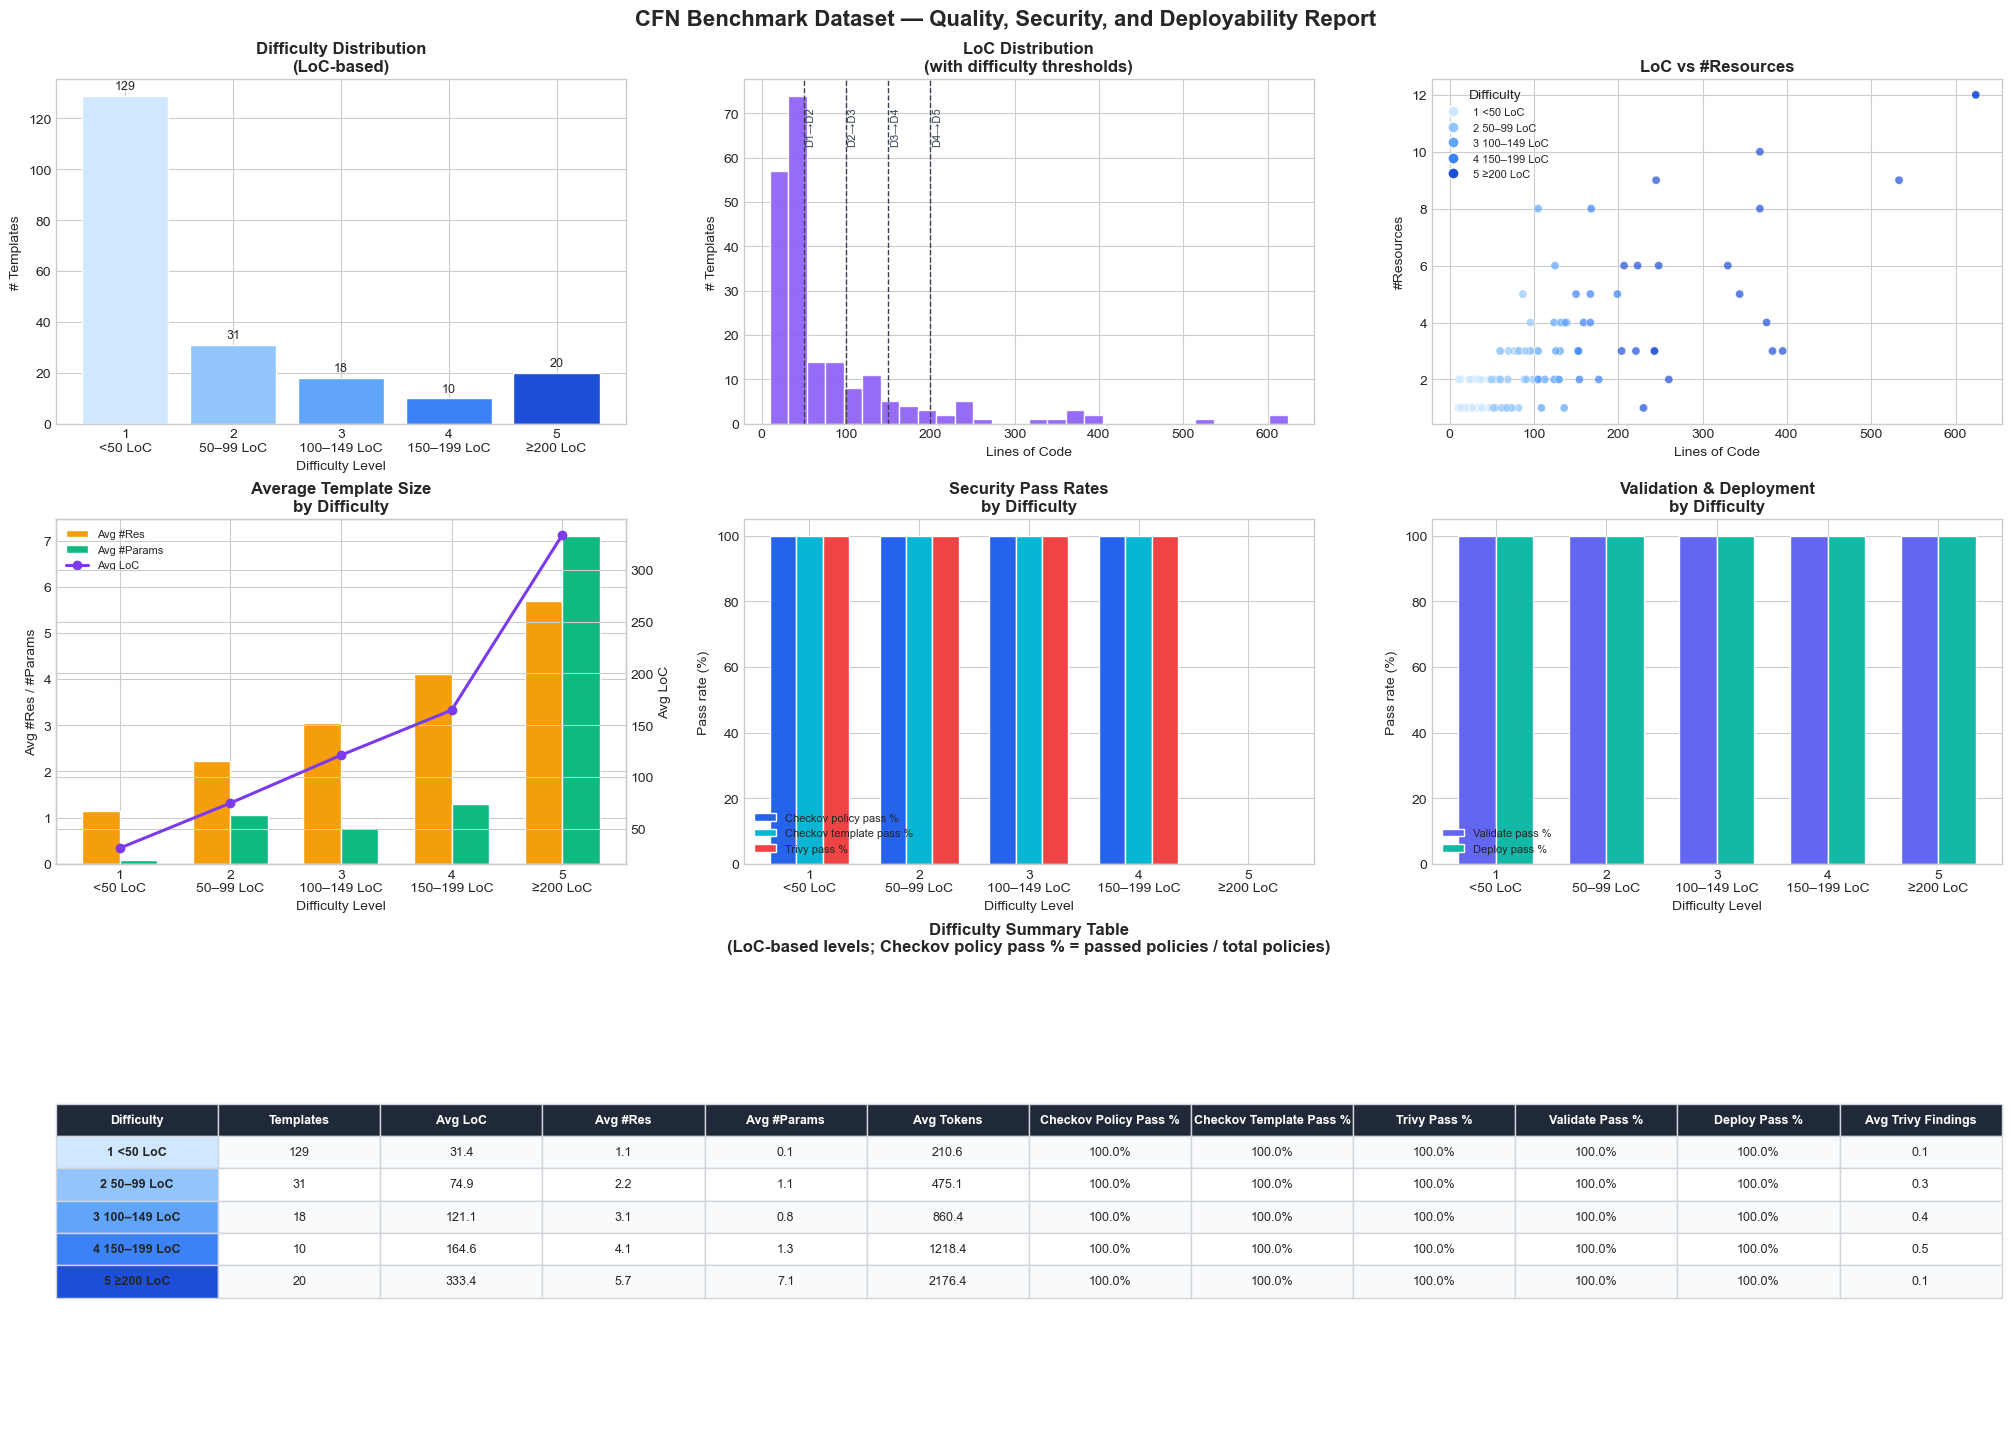


📊 Report saved → cfn_benchmark/dataset/cfn_benchmark_report.png

Difficulty summary:


,Difficulty,Templates,Avg LoC,Avg #Res,Avg #Params,Avg Tokens,Checkov Policy Pass %,Checkov Template Pass %,Trivy Pass %,Validate Pass %,Deploy Pass %,Avg Trivy Findings
0,1 <50 LoC,129,31.434109,1.147287,0.085271,210.573643,100.0,100.0,100.0,100.0,100.0,0.069767
1,2 50–99 LoC,31,74.903226,2.225806,1.064516,475.096774,100.0,100.0,100.0,100.0,100.0,0.258065
2,3 100–149 LoC,18,121.111111,3.055556,0.777778,860.388889,100.0,100.0,100.0,100.0,100.0,0.388889
3,4 150–199 LoC,10,164.600000,4.100000,1.300000,1218.400000,100.0,100.0,100.0,100.0,100.0,0.500000
4,5 ≥200 LoC,20,333.450000,5.700000,7.100000,2176.400000,100.0,100.0,100.0,100.0,100.0,0.100000


In [37]:
# ── 12. Visualisation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ------------------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------------------

levels = [1, 2, 3, 4, 5]
difficulty_labels = {
    1: '1\n<50 LoC',
    2: '2\n50–99 LoC',
    3: '3\n100–149 LoC',
    4: '4\n150–199 LoC',
    5: '5\n≥200 LoC',
}
difficulty_colors = {
    1: '#cfe8ff',
    2: '#93c5fd',
    3: '#60a5fa',
    4: '#3b82f6',
    5: '#1d4ed8',
}

df_vis = df_benchmark.copy()

def pct_true(series):
    if series is None:
        return np.nan
    s = pd.Series(series).dropna()
    return np.nan if len(s) == 0 else (s == True).mean() * 100

def safe_mean(series):
    s = pd.to_numeric(series, errors='coerce')
    return np.nan if s.dropna().empty else s.mean()

def safe_sum(series):
    s = pd.to_numeric(series, errors='coerce')
    return 0 if s.dropna().empty else s.fillna(0).sum()

def checkov_policy_pass_rate(group):
    passed = safe_sum(group['checkov_passed']) if 'checkov_passed' in group.columns else 0
    failed = safe_sum(group['checkov_failed']) if 'checkov_failed' in group.columns else 0
    total = passed + failed
    return np.nan if total == 0 else (passed / total) * 100

def avg_trivy_findings(group):
    cols = [c for c in ['trivy_critical', 'trivy_high', 'trivy_medium', 'trivy_low', 'trivy_unknown']
            if c in group.columns]
    if not cols:
        return np.nan
    vals = group[cols].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
    return np.nan if vals.empty else vals.mean()

# ------------------------------------------------------------------------------
# Difficulty summary table
# ------------------------------------------------------------------------------

summary_rows = []
for d in levels:
    g = df_vis[df_vis['difficulty'] == d].copy()

    row = {
        'Difficulty': difficulty_labels[d].replace('\n', ' '),
        'Templates': len(g),
        'Avg LoC': safe_mean(g['loc']) if 'loc' in g.columns else np.nan,
        'Avg #Res': safe_mean(g['n_resources']) if 'n_resources' in g.columns else np.nan,
        'Avg #Params': safe_mean(g['n_parameters']) if 'n_parameters' in g.columns else np.nan,
        'Avg Tokens': safe_mean(g['tokens']) if 'tokens' in g.columns else np.nan,
        'Checkov Policy Pass %': checkov_policy_pass_rate(g) if not g.empty else np.nan,
        'Checkov Template Pass %': pct_true(g['checkov_pass']) if 'checkov_pass' in g.columns else np.nan,
        'Trivy Pass %': pct_true(g['trivy_pass']) if 'trivy_pass' in g.columns else np.nan,
        'Validate Pass %': pct_true(g['validate_pass']) if 'validate_pass' in g.columns else np.nan,
        'Deploy Pass %': pct_true(g['deploy_pass']) if 'deploy_pass' in g.columns else np.nan,
        'Avg Trivy Findings': avg_trivy_findings(g) if not g.empty else np.nan,
    }
    summary_rows.append(row)

df_diff_summary = pd.DataFrame(summary_rows)

# ------------------------------------------------------------------------------
# Figure layout
# ------------------------------------------------------------------------------

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 14), layout='constrained')
gs = GridSpec(3, 3, figure=fig, height_ratios=[1.0, 1.0, 1.35])

# ── (1) Difficulty distribution (LoC-based) ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
diff_counts = df_vis['difficulty'].value_counts().reindex(levels, fill_value=0)
bars = ax1.bar(
    levels,
    diff_counts.values,
    color=[difficulty_colors[d] for d in levels],
    edgecolor='white',
    linewidth=1.0
)
ax1.set_title('Difficulty Distribution\n(LoC-based)', fontweight='bold')
ax1.set_xlabel('Difficulty Level')
ax1.set_ylabel('# Templates')
ax1.set_xticks(levels)
ax1.set_xticklabels([difficulty_labels[d] for d in levels])
for b, v in zip(bars, diff_counts.values):
    ax1.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + max(diff_counts.max() * 0.01, 1),
        f'{int(v):,}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ── (2) LoC distribution with difficulty thresholds ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
loc_series = pd.to_numeric(df_vis['loc'], errors='coerce').dropna()
bins = min(40, max(12, int(np.sqrt(max(len(loc_series), 1))) * 2))
ax2.hist(loc_series, bins=bins, color='#8b5cf6', edgecolor='white', alpha=0.9)
for x, label in zip([50, 100, 150, 200], ['D1→D2', 'D2→D3', 'D3→D4', 'D4→D5']):
    ax2.axvline(x, color='#374151', linestyle='--', linewidth=1)
    ax2.text(x + 2, ax2.get_ylim()[1] * 0.92, label, rotation=90, va='top', fontsize=8, color='#374151')
ax2.set_title('LoC Distribution\n(with difficulty thresholds)', fontweight='bold')
ax2.set_xlabel('Lines of Code')
ax2.set_ylabel('# Templates')

# ── (3) LoC vs resource count ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
plot_df = df_vis[['loc', 'n_resources', 'difficulty']].copy()
plot_df['loc'] = pd.to_numeric(plot_df['loc'], errors='coerce')
plot_df['n_resources'] = pd.to_numeric(plot_df['n_resources'], errors='coerce')
plot_df = plot_df.dropna()
point_colors = plot_df['difficulty'].map(difficulty_colors)
ax3.scatter(
    plot_df['loc'],
    plot_df['n_resources'],
    c=point_colors,
    alpha=0.7,
    s=36,
    edgecolor='white',
    linewidth=0.5
)
ax3.set_title('LoC vs #Resources', fontweight='bold')
ax3.set_xlabel('Lines of Code')
ax3.set_ylabel('#Resources')

legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=difficulty_labels[d].replace('\n', ' '),
           markerfacecolor=difficulty_colors[d], markersize=8)
    for d in levels
]
ax3.legend(handles=legend_handles, fontsize=8, title='Difficulty', loc='upper left')

# ── (4) Average size by difficulty ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
x = np.arange(len(levels))
w = 0.34

avg_res = df_diff_summary['Avg #Res'].fillna(0).values
avg_par = df_diff_summary['Avg #Params'].fillna(0).values
avg_loc = df_diff_summary['Avg LoC'].fillna(0).values

b1 = ax4.bar(x - w/2, avg_res, width=w, color='#f59e0b', edgecolor='white', label='Avg #Res')
b2 = ax4.bar(x + w/2, avg_par, width=w, color='#10b981', edgecolor='white', label='Avg #Params')
ax4.set_xticks(x)
ax4.set_xticklabels([difficulty_labels[d] for d in levels])
ax4.set_ylabel('Avg #Res / #Params')
ax4.set_xlabel('Difficulty Level')
ax4.set_title('Average Template Size\nby Difficulty', fontweight='bold')

ax4b = ax4.twinx()
l1, = ax4b.plot(x, avg_loc, color='#7c3aed', marker='o', linewidth=2.2, label='Avg LoC')
ax4b.set_ylabel('Avg LoC')

handles = [b1, b2, l1]
labels = ['Avg #Res', 'Avg #Params', 'Avg LoC']
ax4.legend(handles, labels, fontsize=8, loc='upper left')

# ── (5) Security pass rates by difficulty ─────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sec_metrics = pd.DataFrame({
    'Checkov Policy Pass %': df_diff_summary['Checkov Policy Pass %'],
    'Checkov Template Pass %': df_diff_summary['Checkov Template Pass %'],
    'Trivy Pass %': df_diff_summary['Trivy Pass %'],
}, index=levels)

w = 0.24
ax5.bar(x - w, sec_metrics['Checkov Policy Pass %'].fillna(0), width=w,
        color='#2563eb', edgecolor='white', label='Checkov policy pass %')
ax5.bar(x, sec_metrics['Checkov Template Pass %'].fillna(0), width=w,
        color='#06b6d4', edgecolor='white', label='Checkov template pass %')
ax5.bar(x + w, sec_metrics['Trivy Pass %'].fillna(0), width=w,
        color='#ef4444', edgecolor='white', label='Trivy pass %')
ax5.set_xticks(x)
ax5.set_xticklabels([difficulty_labels[d] for d in levels])
ax5.set_ylim(0, 105)
ax5.set_ylabel('Pass rate (%)')
ax5.set_xlabel('Difficulty Level')
ax5.set_title('Security Pass Rates\nby Difficulty', fontweight='bold')
ax5.legend(fontsize=8, loc='lower left')

# ── (6) Validation / deployment or source breakdown ───────────────────────────
ax6 = fig.add_subplot(gs[1, 2])

has_deploy = 'deploy_pass' in df_vis.columns and df_vis['deploy_pass'].notna().any()
if has_deploy or ('validate_pass' in df_vis.columns and df_vis['validate_pass'].notna().any()):
    val_rates = df_diff_summary['Validate Pass %'].fillna(0).values
    dep_rates = df_diff_summary['Deploy Pass %'].fillna(0).values

    ax6.bar(x - 0.17, val_rates, width=0.34, color='#6366f1', edgecolor='white', label='Validate pass %')
    ax6.bar(x + 0.17, dep_rates, width=0.34, color='#14b8a6', edgecolor='white', label='Deploy pass %')
    ax6.set_xticks(x)
    ax6.set_xticklabels([difficulty_labels[d] for d in levels])
    ax6.set_ylim(0, 105)
    ax6.set_ylabel('Pass rate (%)')
    ax6.set_xlabel('Difficulty Level')
    ax6.set_title('Validation & Deployment\nby Difficulty', fontweight='bold')
    ax6.legend(fontsize=8, loc='lower left')
else:
    src_counts = (
        df_vis['source_slug']
        .astype(str)
        .apply(lambda s: s.split('/')[1] if '/' in s else s)
        .value_counts()
        .head(8)
    )
    ax6.barh(src_counts.index, src_counts.values, color='#60a5fa', edgecolor='white')
    ax6.set_title('Templates by Source\n(top 8)', fontweight='bold')
    ax6.set_xlabel('# Templates')
    ax6.invert_yaxis()

# ── (7) Difficulty summary table ──────────────────────────────────────────────
ax_tbl = fig.add_subplot(gs[2, :])
ax_tbl.axis('off')
ax_tbl.set_title(
    'Difficulty Summary Table\n(LoC-based levels; Checkov policy pass % = passed policies / total policies)',
    fontweight='bold',
    pad=12
)

table_cols = [
    'Difficulty', 'Templates', 'Avg LoC', 'Avg #Res', 'Avg #Params',
    'Avg Tokens', 'Checkov Policy Pass %', 'Checkov Template Pass %',
    'Trivy Pass %', 'Validate Pass %', 'Deploy Pass %', 'Avg Trivy Findings'
]

table_df = df_diff_summary[table_cols].copy()

for c in ['Avg LoC', 'Avg #Res', 'Avg #Params', 'Avg Tokens', 'Avg Trivy Findings']:
    table_df[c] = table_df[c].map(lambda v: '' if pd.isna(v) else f'{v:.1f}')

for c in ['Checkov Policy Pass %', 'Checkov Template Pass %', 'Trivy Pass %', 'Validate Pass %', 'Deploy Pass %']:
    table_df[c] = table_df[c].map(lambda v: '' if pd.isna(v) else f'{v:.1f}%')

table_df['Templates'] = table_df['Templates'].map(lambda v: f'{int(v):,}')

cell_text = table_df.values.tolist()
col_labels = table_df.columns.tolist()

tbl = ax_tbl.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
    colLoc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#d1d5db')
    if r == 0:
        cell.set_facecolor('#1f2937')
        cell.set_text_props(color='white', weight='bold')
    elif c == 0:
        level = r
        color = difficulty_colors.get(level, '#eff6ff')
        cell.set_facecolor(color)
        cell.set_text_props(weight='bold')
    else:
        cell.set_facecolor('#f8fafc' if r % 2 == 1 else 'white')

plt.suptitle(
    'CFN Benchmark Dataset — Quality, Security, and Deployability Report',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

out_png = DATASET_DIR / 'cfn_benchmark_report.png'
plt.savefig(out_png, dpi=180, bbox_inches='tight')
plt.show()

print(f'\n📊 Report saved → {out_png}')
print('\nDifficulty summary:')
display(df_diff_summary)